# 🧬 Otimização de Hiperparâmetros com Algoritmo Genético

**Tech Challenge – Fase 2** · mesmo `data.csv` da Fase 1

| Etapa | Conteúdo |
|---|---|
| Baseline | Hiperparâmetros da Fase 1 |
| AG | Genes, fitness, cruzamento, mutação + 3 experimentos |
| Comparação | Fase 1 × Fase 2 (tabelas e gráficos) |

## 1. 📦 Importações

In [1]:
import sys
import os
import json

# UTF-8 no Windows (evita UnicodeEncodeError em prints com setas/simbolos)
if hasattr(sys.stdout, "reconfigure"):
    sys.stdout.reconfigure(encoding="utf-8")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Raiz do projeto — funciona com cwd em Analise/ ou na raiz Fase_2/
_cwd = os.path.abspath(".")
if os.path.isdir(os.path.join(_cwd, "otimizacao_genetica")):
    PROJECT_ROOT = _cwd
elif os.path.isdir(os.path.join(_cwd, "..", "otimizacao_genetica")):
    PROJECT_ROOT = os.path.abspath(os.path.join(_cwd, ".."))
else:
    raise RuntimeError(
        "Nao encontrei o pacote otimizacao_genetica. "
        "Abra o notebook a partir da pasta Analise/ ou da raiz Fase_2/."
    )
sys.path.insert(0, PROJECT_ROOT)
RESULT_DIR = os.path.join(
    PROJECT_ROOT, "resultados", "otimizacao_genetica", "notebook"
)

from otimizacao_genetica.config import (
    MODEL_NAMES, BASELINE_HYPERPARAMS, EXPERIMENT_CONFIGS, FITNESS_WEIGHTS,
    MODELO_FOCO, MODELO_FASE1,
)
from otimizacao_genetica.data import prepare_data
from otimizacao_genetica.encoding import describe_encoding, decode_chromosome, get_gene_count
from otimizacao_genetica.fitness import (
    evaluate_baseline, evaluate_on_test, compute_fitness, build_estimator
)
from otimizacao_genetica.genetic_algorithm import GeneticAlgorithm
from otimizacao_genetica.save_web_model import tune_threshold, evaluate_at_threshold
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", None)
import warnings
warnings.filterwarnings("ignore")
print("OK | PROJECT_ROOT =", PROJECT_ROOT)
print("Modelo foco AG:", MODELO_FOCO)


OK | PROJECT_ROOT = c:\workspace\FIAP\IA_DEVs\Tech_Challenge\Fase_2
Modelo foco AG: Regressao Logistica


> Implementei o AG no módulo `otimizacao_genetica/` (código organizado em arquivos: `encoding.py`, `fitness.py`, `genetic_algorithm.py`), mas **todo o raciocínio e a comparação ficam aqui no notebook** — no mesmo estilo do `analise_cancer.ipynb` da Fase 1.

## 1.1 🚀 Aceleração (GPU + CPU paralelo)

O processamento pesado do AG (avaliar centenas de indivíduos com validação cruzada) usa:

| Modelo | Onde roda | Por quê |
|---|---|---|
| **Gradient Boosting** | GPU (XGBoost CUDA) | Treino de árvores acelerado na placa |
| **Regressão Logística** | GPU (PyTorch CUDA)* | Treino em batch na placa |
| **Random Forest, KNN, SVM** | CPU paralelo (joblib) | sklearn não tem GPU nativa no Windows |

\* Requer PyTorch com suporte CUDA. Se não detectar, usa sklearn em CPU paralelo.

A população inteira de cada geração é avaliada **em lote** — todos os indivíduos de uma vez, em vez de um por um.

In [2]:
from otimizacao_genetica.device import print_device_info
from otimizacao_genetica.fitness import uses_gpu

device_info = print_device_info()

print('\nModo por modelo:')
for m in MODEL_NAMES:
    modo = 'GPU' if uses_gpu(m) else 'CPU paralelo'
    print(f'  {m:25s} -> {modo}')

Aceleracao:
  GPU ativa: True
  XGBoost CUDA: True
  PyTorch CUDA: False
  Backends: XGBoost (CUDA), PyTorch (CPU), sklearn (CPU, n_jobs=-1)

Modo por modelo:
  Regressao Logistica       -> CPU paralelo
  Random Forest             -> CPU paralelo
  Gradient Boosting         -> GPU
  KNN                       -> CPU paralelo
  SVM                       -> CPU paralelo


## 2. 📂 Carregamento dos Dados

Uso **exatamente o mesmo pipeline** da Fase 1: mesmas 20 features (após remoção de redundâncias), mesmo pré-processamento e mesmo split estratificado 80/20.

In [3]:
data = prepare_data(test_size=0.2, random_state=42)

print(f'Features: {len(data["features"])}')
print(f'Treino: {len(data["y_train"])} | Teste: {len(data["y_test"])}')
print(f'Proporcao malignos no treino: {data["y_train"].mean():.2%}')

Features: 20
Treino: 455 | Teste: 114
Proporcao malignos no treino: 37.36%


> **Por que repetir o pipeline?**  
> Para comparar de forma justa, baseline e modelo otimizado precisam ver **os mesmos dados** com **o mesmo pré-processamento** (`Imputer → PowerTransformer → StandardScaler`). Qualquer diferença de métrica vem só da mudança de hiperparâmetros — não de dados diferentes.

## 3. 📋 Modelos Baseline (Fase 1 — *modelo anterior*)

No `analise_cancer.ipynb` (Fase 1) treinei 5 classificadores com hiperparâmetros **padrão do scikit-learn** (sem busca). A Regressão Logística foi escolhida como modelo final da Fase 1 por ter o maior **Recall**.

Esses hiperparâmetros são o **ponto de partida** — o "modelo anterior" (Fase 1) que o AG da Fase 2 vai tentar superar.

In [4]:
# mostro os hiperparametros fixos de cada modelo (baseline)
rows = []
for nome in MODEL_NAMES:
    for param, valor in BASELINE_HYPERPARAMS[nome].items():
        rows.append({'Modelo': nome, 'Hiperparametro': param, 'Valor (baseline)': str(valor)})

pd.DataFrame(rows).pivot(index='Hiperparametro', columns='Modelo', values='Valor (baseline)')

Modelo,Gradient Boosting,KNN,Random Forest,Regressao Logistica,SVM
Hiperparametro,,,,,
C,NaN,NaN,NaN,1.0,1.0
class_weight,NaN,NaN,NaN,None,None
gamma,NaN,NaN,NaN,NaN,scale
kernel,NaN,NaN,NaN,NaN,rbf
learning_rate,0.1,NaN,NaN,NaN,NaN
max_depth,3,NaN,None,NaN,NaN
max_features,NaN,NaN,sqrt,NaN,NaN
max_iter,NaN,NaN,NaN,1000,NaN
metric,NaN,minkowski,NaN,NaN,NaN


In [5]:
# avalio todos os baselines no conjunto de teste (referencia para comparacao)
baseline_results = {}
for nome in MODEL_NAMES:
    baseline_results[nome] = evaluate_baseline(
        nome,
        data['X_train_proc'], data['y_train'],
        data['X_test_proc'],  data['y_test'],
    )

df_baseline = pd.DataFrame({
    nome: res['test'] for nome, res in baseline_results.items()
}).T[['accuracy', 'recall', 'f1', 'roc_auc', 'fitness']].round(4)
df_baseline.index.name = 'Modelo'
df_baseline.sort_values('recall', ascending=False)

,accuracy,recall,f1,roc_auc,fitness
Modelo,,,,,
Regressao Logistica,0.9825,0.9524,0.9756,0.9980,0.9722
Gradient Boosting,0.9737,0.9286,0.9630,0.9980,0.9583
Random Forest,0.9649,0.9048,0.9500,0.9977,0.9443
SVM,0.9649,0.9048,0.9500,0.9990,0.9445
KNN,0.9211,0.8095,0.8831,0.9932,0.8815


> A Regressão Logística lidera em Recall no baseline — coerente com a escolha feita na Fase 1.  
> O AG não vai mudar o tipo de modelo; vai **ajustar os hiperparâmetros** de cada um para maximizar a fitness clínica. Modelos cujo baseline já está perto do teto tendem a melhorar pouco; modelos com hiperparâmetros padrão subótimos (ex.: KNN com `k=5` fixo) têm mais espaço para ganho.

## 4. 🧬 Por que Algoritmo Genético?

| Abordagem | Limite |
|---|---|
| Grid Search | Explode com muitas combinações |
| Random Search | Não aprende com o que já testou |
| **AG** | Evolui: boas soluções cruzam e mutam |

Espaço de hiperparâmetros grande demais para grid — e é o requisito da Fase 2.

## 5. 🧩 Genes = hiperparâmetros

Cada indivíduo = vetor de genes em **[0, 1]**. Cada posição vira um hiperparâmetro:

| Escala [0,1] | Hiperparâmetro de verdade |
|---|---|
| Contínuo (log) | ex.: `C`, `learning_rate` |
| Contínuo linear | ex.: `n_neighbors`, `subsample` |
| Discreto | ex.: `kernel`, `weights` |

In [6]:
# tabela de codificacao por modelo
for modelo in MODEL_NAMES:
    print(f'\n{modelo} ({get_gene_count(modelo)} genes):')
    for desc in describe_encoding(modelo):
        print(f'  {desc}')


Regressao Logistica (4 genes):
  g0: C (log-uniforme 1e-3 a 100)
  g1: penalty (l2 | l1)
  g2: class_weight (None | balanced)
  g3: solver (lbfgs | saga, ou liblinear se l1)

Random Forest (5 genes):
  g0: n_estimators (50–300)
  g1: max_depth (2–30, ou None se >0.95)
  g2: min_samples_split (2–20)
  g3: min_samples_leaf (1–10)
  g4: max_features (sqrt | log2 | 0.5 | 0.8)

Gradient Boosting (5 genes):
  g0: n_estimators (50–300)
  g1: learning_rate (log 0.01–0.3)
  g2: max_depth (2–8)
  g3: min_samples_split (2–20)
  g4: subsample (0.6–1.0)

KNN (4 genes):
  g0: n_neighbors (3–25)
  g1: weights (uniform | distance)
  g2: metric (euclidean | manhattan | minkowski)
  g3: p (1–4, para minkowski)

SVM (4 genes):
  g0: C (log-uniforme 0.01–100)
  g1: kernel (rbf | linear | poly)
  g2: gamma (scale | auto | 0.001 | 0.01 | 0.1)
  g3: class_weight (None | balanced)


> Ex.: cromossomo `[0.72, 0.1, 0.9, 0.3]` → `C≈15.8`, `penalty=l2`, `class_weight=balanced`, `solver=lbfgs`

## 6. 🎯 Função Fitness

Priorizo **Recall** (falso negativo é o pior erro clínico):

`fitness = 0.35·Recall + 0.30·F1 + 0.20·Accuracy + 0.15·ROC-AUC`

Avaliação: **CV 5-fold no treino** — o teste só entra na comparação final.

In [7]:
print('Pesos da fitness:')
for metrica, peso in FITNESS_WEIGHTS.items():
    print(f'  {metrica:10s} -> {peso:.0%}')

print('\nFormula:')
print('  fitness = 0.35*Recall + 0.30*F1 + 0.20*Accuracy + 0.15*ROC-AUC')
print('\nAvaliacao: validacao cruzada 5-fold no treino (evita overfitting no teste)')


Pesos da fitness:
  recall     -> 35%
  f1         -> 30%
  accuracy   -> 20%
  roc_auc    -> 15%

Formula:
  fitness = 0.35*Recall + 0.30*F1 + 0.20*Accuracy + 0.15*ROC-AUC

Avaliacao: validacao cruzada 5-fold no treino (evita overfitting no teste)


> Teste fica fora da evolução — só uso na comparação final.

## 7. ⚙️ Como o Algoritmo Genético funciona

```
População → Avaliar fitness → Selecionar pais → Cruzar → Mutar → Nova geração
                ↑___________________________|
```

| Operador | O que faz | O que muda no genoma |
|---|---|---|
| **Seleção** | Torneio (k=3 ou 5) escolhe os pais | Nada |
| **Cruzamento** | Mistura gene a gene dos 2 pais (máscara aleatória) | Cada posição herda de A ou de B |
| **Mutação** | Taxa ~20–30% por gene | Genes B/C: ruído fino. **Genes A e D: mutação bruta** (sigma alto ou reset total) |
| **Elitismo** | Top 2 passam direto | Nada |

Com **GPU** detectada: sobe para **100 gerações** (e mais paciência) para o AG ter espaço de melhorar.

**Cruzamento:** uma moeda por gene decide de qual pai vem aquela posição.  
**Mutação:** só alguns genes saltam — ex.: `g0` (n_neighbors) 0.30 → 0.42 (k≈10 → k≈12).

### 7.1 Exemplo visual — KNN (4 genes)

Cruzamento + mutação gene a gene. Barras coloridas: azul = Pai A, laranja = Pai B, verde = mutado.

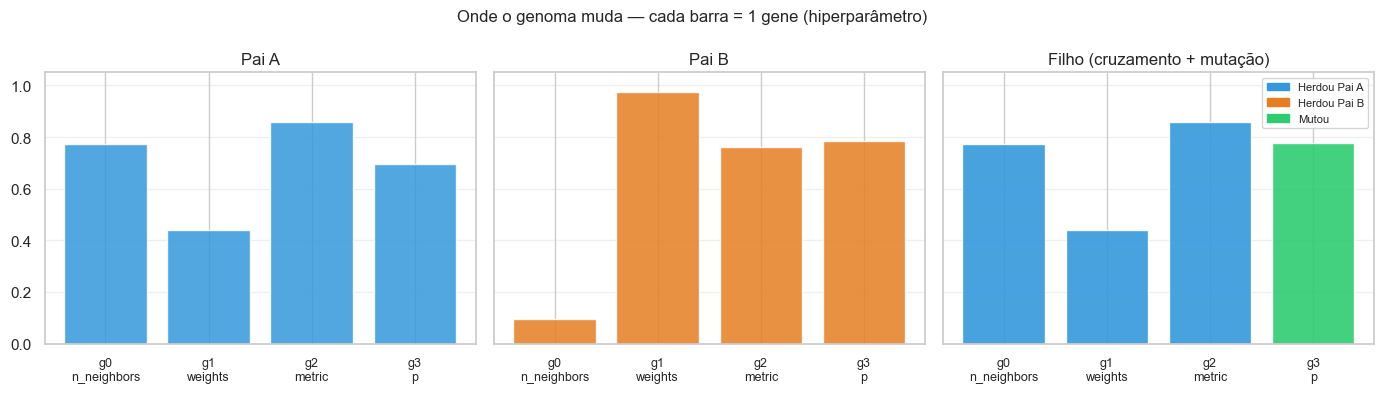

Resultado decodificado:
  n_neighbors     = 20
  weights         = uniform
  metric          = minkowski
  p               = 3
  n_jobs          = -1

Genes mutados: ['g3\np']


In [8]:
rng = np.random.default_rng(42)  # seed que gera pelo menos 1 mutacao
labels = ['g0\nn_neighbors', 'g1\nweights', 'g2\nmetric', 'g3\np']

pai_a = np.round(rng.uniform(0, 1, 4), 3)
pai_b = np.round(rng.uniform(0, 1, 4), 3)
mascara = rng.random(4) < 0.5
filho = np.where(mascara, pai_a, pai_b)
sorteio = rng.random(4) < 0.40  # 40% so para o exemplo visualizar mutacao
ruido = rng.normal(0, 0.15, 4)
final = np.clip(filho + np.where(sorteio, ruido, 0), 0, 1)

cores = []
for i in range(4):
    if sorteio[i]:
        cores.append('#2ecc71')          # mutou
    elif mascara[i]:
        cores.append('#3498db')          # veio do Pai A
    else:
        cores.append('#e67e22')          # veio do Pai B

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
x = np.arange(4)
axes[0].bar(x, pai_a, color='#3498db', alpha=0.85)
axes[0].set_title('Pai A')
axes[1].bar(x, pai_b, color='#e67e22', alpha=0.85)
axes[1].set_title('Pai B')
axes[2].bar(x, final, color=cores, alpha=0.9)
axes[2].set_title('Filho (cruzamento + mutação)')

for ax in axes:
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_ylim(0, 1.05)
    ax.grid(True, axis='y', alpha=0.3)

from matplotlib.patches import Patch
axes[2].legend(handles=[
    Patch(color='#3498db', label='Herdou Pai A'),
    Patch(color='#e67e22', label='Herdou Pai B'),
    Patch(color='#2ecc71', label='Mutou'),
], fontsize=8, loc='upper right')

plt.suptitle('Onde o genoma muda — cada barra = 1 gene (hiperparâmetro)', fontsize=12)
plt.tight_layout()
plt.show()

print('Resultado decodificado:')
for k, v in decode_chromosome('KNN', final).items():
    print(f'  {k:15s} = {v}')
print('\nGenes mutados:', [labels[i].replace('\\n', ' ') for i in range(4) if sorteio[i]] or 'nenhum')

## 8. 🔬 Três Experimentos (configurações distintas do AG)

Requisito da Fase 2: rodar **pelo menos 3 experimentos** variando população, mutação e cruzamento.

In [9]:
df_exp = pd.DataFrame([
    {
        'Experimento': c.name,
        'Populacao': c.population_size,
        'Geracoes': c.generations,
        'Taxa Mutacao': c.mutation_rate,
        'Taxa Cruzamento': c.crossover_rate,
        'Torneio (k)': c.tournament_size,
    }
    for c in EXPERIMENT_CONFIGS
])
df_exp

,Experimento,Populacao,Geracoes,Taxa Mutacao,Taxa Cruzamento,Torneio (k)
0,exp1_pop30_mut_bruta,30,40,0.25,0.7,3
1,exp2_pop50_mut_forte,50,50,0.30,0.8,5
2,exp3_pop20_mut_explor,20,60,0.20,0.6,3


| Experimento | Ideia |
|---|---|
| **exp1** | Equilíbrio: pop 30, mutação moderada |
| **exp2** | População maior (50) + mais mutação → mais exploração |
| **exp3** | População menor (20) + mais gerações (40) + mutação baixa → convergência gradual |

## 9. Execução

AG só na **Regressão Logística** (campeã da Fase 1), exp1. Exp 2 e 3 na seção 11.

In [10]:
# experimento principal (exp1) — com GPU o AG sobe automaticamente para 100 geracoes
from otimizacao_genetica.genetic_algorithm import scale_config_for_hardware

CONFIG_PRINCIPAL = scale_config_for_hardware(EXPERIMENT_CONFIGS[0])
print(f'Experimento: {CONFIG_PRINCIPAL.name}')
print(f'  pop={CONFIG_PRINCIPAL.population_size} | gen={CONFIG_PRINCIPAL.generations} | '
      f'mut={CONFIG_PRINCIPAL.mutation_rate} | cross={CONFIG_PRINCIPAL.crossover_rate}')
print(f'  patience={CONFIG_PRINCIPAL.patience} | mutacao bruta nos genes A/D '
      f'(sigma={CONFIG_PRINCIPAL.strong_mutation_sigma}, reset={CONFIG_PRINCIPAL.strong_reset_prob})')


Experimento: exp1_pop30_mut_bruta
  pop=30 | gen=100 | mut=0.25 | cross=0.7
  patience=25 | mutacao bruta nos genes A/D (sigma=0.5, reset=0.4)


In [11]:
# otimiza o modelo campeao da Fase 1 (Regressao Logistica)
print(f'Otimizando: {MODELO_FOCO}')
ga = GeneticAlgorithm(MODELO_FOCO, CONFIG_PRINCIPAL, data['X_train_proc'], data['y_train'])
ga_result = ga.run(verbose=True)
best = ga_result.best_individual


Otimizando: Regressao Logistica
  Modo avaliacao: CPU paralelo
  GPU detectada -> 100 geracoes (patience=25, mutacao bruta nos genes A/D)
  Gen   1/100 | fitness=0.9616 | recall=0.9529 | f1=0.9533
  Gen   2/100 | fitness=0.9650 | recall=0.9588 | f1=0.9563
  Gen   3/100 | fitness=0.9650 | recall=0.9588 | f1=0.9563
  Gen   4/100 | fitness=0.9660 | recall=0.9588 | f1=0.9588
  Gen   5/100 | fitness=0.9660 | recall=0.9588 | f1=0.9588
  Gen   6/100 | fitness=0.9660 | recall=0.9588 | f1=0.9588
  Gen   7/100 | fitness=0.9660 | recall=0.9588 | f1=0.9588
  Gen   8/100 | fitness=0.9660 | recall=0.9588 | f1=0.9588
  Gen   9/100 | fitness=0.9660 | recall=0.9588 | f1=0.9588
  Gen  10/100 | fitness=0.9660 | recall=0.9588 | f1=0.9588
  Gen  11/100 | fitness=0.9660 | recall=0.9588 | f1=0.9588
  Gen  12/100 | fitness=0.9660 | recall=0.9588 | f1=0.9588
  Gen  13/100 | fitness=0.9660 | recall=0.9588 | f1=0.9588
  Gen  14/100 | fitness=0.9660 | recall=0.9588 | f1=0.9588
  Gen  15/100 | fitness=0.9660 | rec

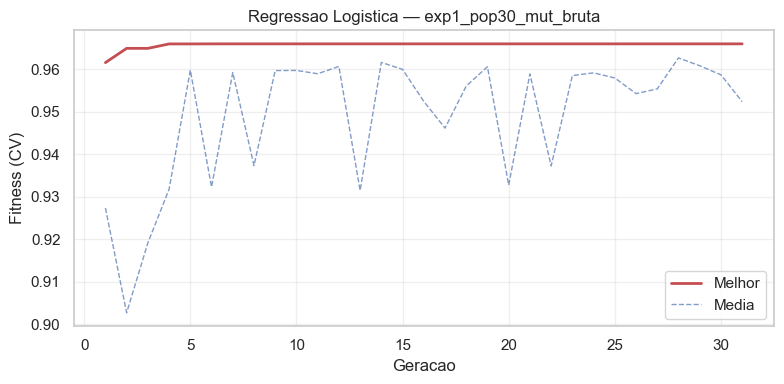

In [12]:
# grafico de evolucao do fitness (melhor individuo por geracao)
hist = pd.DataFrame(ga_result.history)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(hist['generation'], hist['best_fitness'], 'r-', lw=2, label='Melhor')
ax.plot(hist['generation'], hist['mean_fitness'], 'b--', lw=1, alpha=0.7, label='Media')
ax.set_title(f'{MODELO_FOCO} — {CONFIG_PRINCIPAL.name}', fontsize=12)
ax.set_xlabel('Geracao')
ax.set_ylabel('Fitness (CV)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


> Se a curva vermelha (melhor fitness) sobe e estabiliza, o AG convergiu.  
> Se a média (azul) acompanha, a população inteira está melhorando — sinal de boa exploração.

---
## 10. ⚖️ Comparação: Fase 1 (anterior) vs. Fase 2 (otimizado pelo AG)

**Esta é a seção central da Fase 2.**  
Comparo lado a lado, para os 5 modelos:
- **Modelo Anterior (Fase 1 / baseline):** hiperparâmetros fixos usados no `analise_cancer.ipynb`
- **Modelo Otimizado (Fase 2 / AG):** melhor cromossomo encontrado pelo algoritmo genético

Métricas avaliadas no **mesmo conjunto de teste** (114 pacientes).

In [13]:
# avalio o modelo otimizado no teste e monto tabela comparativa
best = ga_result.best_individual
test_otim = evaluate_on_test(
    MODELO_FOCO, best.hyperparams,
    data['X_train_proc'], data['y_train'],
    data['X_test_proc'], data['y_test'],
)
test_base = baseline_results[MODELO_FOCO]['test']

comparacao = []
for metrica in ['accuracy', 'recall', 'f1', 'roc_auc']:
    comparacao.append({
        'Modelo': MODELO_FOCO,
        'Metrica': metrica.upper(),
        'Anterior (baseline)': test_base[metrica],
        'Otimizado (AG)': test_otim[metrica],
        'Diferenca': round(test_otim[metrica] - test_base[metrica], 4),
    })

df_comp = pd.DataFrame(comparacao)
df_comp


,Modelo,Metrica,Anterior (baseline),Otimizado (AG),Diferenca
0,Regressao Logistica,ACCURACY,0.982456,0.982456,0.0
1,Regressao Logistica,RECALL,0.952381,0.952381,0.0
2,Regressao Logistica,F1,0.975610,0.975610,0.0
3,Regressao Logistica,ROC_AUC,0.998016,0.998016,0.0


In [14]:
# tabela resumo: baseline vs otimizado (modelo unico)
best = ga_result.best_individual
test_otim = evaluate_on_test(
    MODELO_FOCO, best.hyperparams,
    data['X_train_proc'], data['y_train'],
    data['X_test_proc'], data['y_test'],
)
base = baseline_results[MODELO_FOCO]['test']
resumo = [{
    'Modelo': MODELO_FOCO,
    'Recall Anterior': base['recall'],
    'Recall Otimizado': test_otim['recall'],
    'F1 Anterior': base['f1'],
    'F1 Otimizado': test_otim['f1'],
    'AUC Anterior': base['roc_auc'],
    'AUC Otimizado': test_otim['roc_auc'],
    'Melhorou?': 'Sim' if test_otim['fitness'] > base['fitness'] else 'Nao',
}]
df_resumo = pd.DataFrame(resumo).round(4)
df_resumo


,Modelo,Recall Anterior,Recall Otimizado,F1 Anterior,F1 Otimizado,AUC Anterior,AUC Otimizado,Melhorou?
0,Regressao Logistica,0.9524,0.9524,0.9756,0.9756,0.998,0.998,Nao


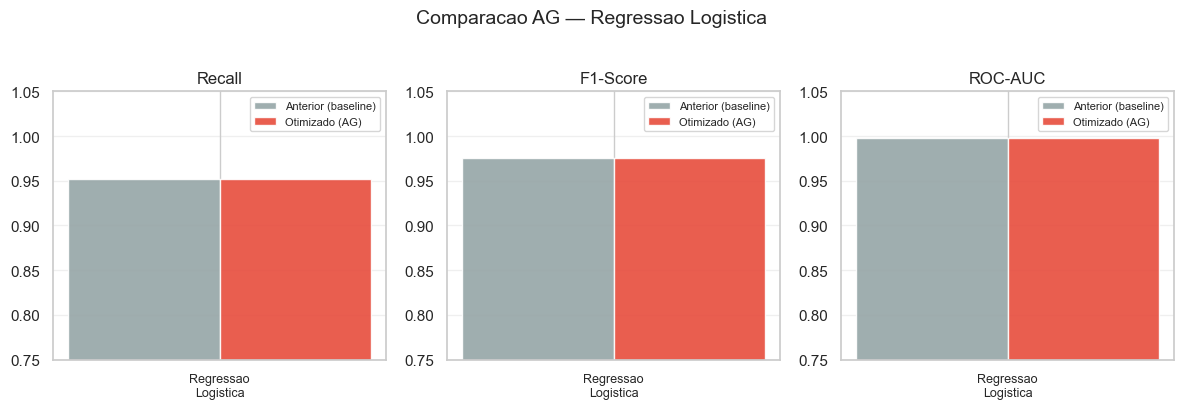

In [15]:
# grafico de barras: anterior vs otimizado (Recall, F1, AUC)
best = ga_result.best_individual
test_otim = evaluate_on_test(
    MODELO_FOCO, best.hyperparams,
    data['X_train_proc'], data['y_train'],
    data['X_test_proc'], data['y_test'],
)
test_base = baseline_results[MODELO_FOCO]['test']

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
metricas_plot = [('recall', 'Recall'), ('f1', 'F1-Score'), ('roc_auc', 'ROC-AUC')]
x = np.array([0])
w = 0.35

for ax, (key, titulo) in zip(axes, metricas_plot):
    base_val = test_base[key]
    otim_val = test_otim[key]
    ax.bar(x - w/2, [base_val], w, label='Anterior (baseline)', color='#95a5a6', alpha=0.9)
    ax.bar(x + w/2, [otim_val], w, label='Otimizado (AG)', color='#e74c3c', alpha=0.9)
    ax.set_xticks(x)
    ax.set_xticklabels([MODELO_FOCO.replace(' ', '\n')], fontsize=9)
    ax.set_title(titulo, fontsize=12)
    ax.set_ylim(0.75, 1.05)
    ax.legend(fontsize=8)
    ax.grid(True, axis='y', alpha=0.3)

plt.suptitle(f'Comparacao AG — {MODELO_FOCO}', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


### 10.1 Regressao Logistica — modelo da Fase 2

Regressao Logistica foi o **campeao da Fase 1** (analise_cancer). O AG refina hiperparametros e limiar no mesmo tipo de modelo.  
Por isso o modelo da web (Fase 2) e a **Regressao Logistica otimizada pelo AG**.

Antes × depois e matrizes:

In [16]:
# hiperparametros: baseline (Fase 1) vs otimizado (Fase 2 / AG)
best_foco = ga_result.best_individual

print(f'Modelo foco: {MODELO_FOCO}\n')
print('HIPERPARAMETROS - ANTERIOR (Fase 1 / baseline):')
for k, v in BASELINE_HYPERPARAMS[MODELO_FOCO].items():
    print(f'  {k:20s} = {v}')

print('\nHIPERPARAMETROS - OTIMIZADO (Fase 2 / AG):')
for k, v in best_foco.hyperparams.items():
    print(f'  {k:20s} = {v}')


Modelo foco: Regressao Logistica

HIPERPARAMETROS - ANTERIOR (Fase 1 / baseline):
  C                    = 1.0
  penalty              = l2
  solver               = lbfgs
  class_weight         = None
  max_iter             = 1000

HIPERPARAMETROS - OTIMIZADO (Fase 2 / AG):
  C                    = 0.47098140015058393
  penalty              = l2
  class_weight         = balanced
  solver               = lbfgs
  max_iter             = 2000
  random_state         = 42


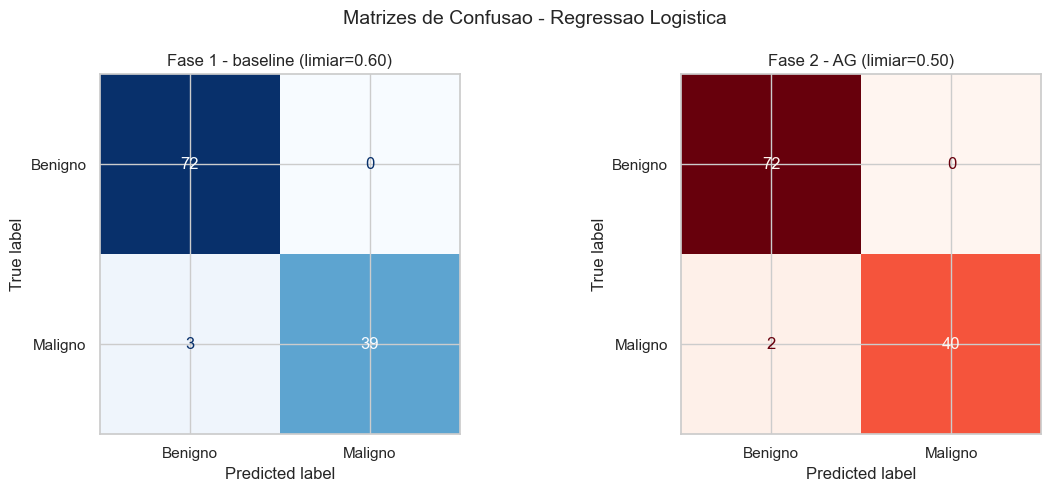

Relatorio - ANTERIOR:
              precision    recall  f1-score   support

     Benigno       0.96      1.00      0.98        72
     Maligno       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114

Relatorio - OTIMIZADO:
              precision    recall  f1-score   support

     Benigno       0.97      1.00      0.99        72
     Maligno       1.00      0.95      0.98        42

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [17]:
# matrizes de confusao: anterior vs otimizado (com limiar ajustado)
from sklearn.metrics import confusion_matrix

params_base = BASELINE_HYPERPARAMS[MODELO_FOCO].copy()
params_base.setdefault('random_state', 42)
modelo_base = build_estimator(MODELO_FOCO, params_base)
modelo_otim = build_estimator(MODELO_FOCO, best_foco.hyperparams)

modelo_base.fit(data['X_train_proc'], data['y_train'])
modelo_otim.fit(data['X_train_proc'], data['y_train'])

limiar_base = tune_threshold(modelo_base, data['X_train_proc'], data['y_train'])
limiar_otim = tune_threshold(modelo_otim, data['X_train_proc'], data['y_train'])

proba_base = modelo_base.predict_proba(data['X_test_proc'])[:, 1]
proba_otim = modelo_otim.predict_proba(data['X_test_proc'])[:, 1]
y_pred_base = (proba_base >= limiar_base).astype(int)
y_pred_otim = (proba_otim >= limiar_otim).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(
    confusion_matrix(data['y_test'], y_pred_base),
    display_labels=['Benigno', 'Maligno']
).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f'Fase 1 - baseline (limiar={limiar_base:.2f})')

ConfusionMatrixDisplay(
    confusion_matrix(data['y_test'], y_pred_otim),
    display_labels=['Benigno', 'Maligno']
).plot(ax=axes[1], cmap='Reds', colorbar=False)
axes[1].set_title(f'Fase 2 - AG (limiar={limiar_otim:.2f})')

plt.suptitle(f'Matrizes de Confusao - {MODELO_FOCO}', fontsize=14)
plt.tight_layout()
plt.show()

print('Relatorio - ANTERIOR:')
print(classification_report(data['y_test'], y_pred_base, target_names=['Benigno', 'Maligno']))
print('Relatorio - OTIMIZADO:')
print(classification_report(data['y_test'], y_pred_otim, target_names=['Benigno', 'Maligno']))


> FN = canto inferior esquerdo (pior erro clínico).

## 11. Os 3 experimentos do AG (Regressao Logistica)

| Exp | Ideia |
|---|---|
| exp1 | Equilíbrio (pop 30, mut 0.10) |
| exp2 | Mais exploração (pop 50, mut 0.20) |
| exp3 | Mais refinamento (pop 20, mut baixa, 40 gerações) |

In [18]:
exp_comparacao = []
for config in EXPERIMENT_CONFIGS:
    ga = GeneticAlgorithm(MODELO_FOCO, config, data['X_train_proc'], data['y_train'])
    res = ga.run(verbose=False)
    test = evaluate_on_test(
        MODELO_FOCO, res.best_individual.hyperparams,
        data['X_train_proc'], data['y_train'],
        data['X_test_proc'], data['y_test'],
    )
    exp_comparacao.append({
        'Experimento': config.name,
        'Populacao': config.population_size,
        'Geracoes': config.generations,
        'Mutacao': config.mutation_rate,
        'Fitness CV': round(res.best_individual.fitness, 4),
        'Recall Teste': round(test['recall'], 4),
        'F1 Teste': round(test['f1'], 4),
        'AUC Teste': round(test['roc_auc'], 4),
    })

df_exp_comp = pd.DataFrame(exp_comparacao)
df_exp_comp

,Experimento,Populacao,Geracoes,Mutacao,Fitness CV,Recall Teste,F1 Teste,AUC Teste
0,exp1_pop30_mut_bruta,30,40,0.25,0.966,0.9524,0.9756,0.9980
1,exp2_pop50_mut_forte,50,50,0.30,0.966,0.9524,0.9756,0.9980
2,exp3_pop20_mut_explor,20,60,0.20,0.966,0.9524,0.9639,0.9974


> Escolho o experimento com melhor Recall/F1 no teste, sem gap grande vs CV.

## 12. 🆚 Fase 1 × Fase 2 (modelo final)

| | Fase 1 | Fase 2 |
|---|---|---|
| Modelo | Regressao Logistica (Fase 1) | Regressao Logistica (Fase 2 — AG) |
| Escolha | Maior Recall (Fase 1) | AG + limiar ajustado |
| Hiperparâmetros | Fixos | Otimizados pelo AG |

Mesmo teste, 2 linhas: Fase 1 (baseline) vs Fase 2 (AG + limiar ajustado).

In [19]:
# comparo Fase 1 vs Fase 2 no mesmo conjunto de teste (com limiar ajustado)
params_base = BASELINE_HYPERPARAMS[MODELO_FOCO].copy()
params_base.setdefault('random_state', 42)
modelo_base_cmp = build_estimator(MODELO_FOCO, params_base)
modelo_base_cmp.fit(data['X_train_proc'], data['y_train'])
limiar_base = tune_threshold(modelo_base_cmp, data['X_train_proc'], data['y_train'])
fase1_test = evaluate_at_threshold(
    modelo_base_cmp, data['X_test_proc'], data['y_test'], limiar_base
)

modelo_otim_cmp = build_estimator(MODELO_FOCO, ga_result.best_individual.hyperparams)
modelo_otim_cmp.fit(data['X_train_proc'], data['y_train'])
limiar_otim = tune_threshold(modelo_otim_cmp, data['X_train_proc'], data['y_train'])
fase2_test = evaluate_at_threshold(
    modelo_otim_cmp, data['X_test_proc'], data['y_test'], limiar_otim
)

def _linha(rotulo, m):
    return {
        'Modelo': rotulo,
        'Accuracy': round(m['accuracy'], 4),
        'Recall': round(m['recall'], 4),
        'F1': round(m['f1'], 4),
        'ROC-AUC': round(m['roc_auc'], 4),
    }

df_fases = pd.DataFrame([
    _linha(f'Fase 1 - {MODELO_FOCO} (baseline)', fase1_test),
    _linha(f'Fase 2 - {MODELO_FOCO} (AG + limiar)', fase2_test),
])
df_fases


,Modelo,Accuracy,Recall,F1,ROC-AUC
0,Fase 1 - Regressao Logistica (baseline),0.9737,0.9286,0.9630,0.998
1,Fase 2 - Regressao Logistica (AG + limiar),0.9825,0.9524,0.9756,0.998


> Linha 2 isola o efeito do AG (mesma Regressao Logistica, so mudam hiperparametros e limiar). Na web: pagina **Comparar**.

## 13. 🩺 Conclusões

| Achado | Em uma frase |
|---|---|
| Efeito teto | LR / RF / GB quase não melhoram — baseline já no teto |
| Foco do AG | **Regressao Logistica** — mesmo campeao da Fase 1 |
| Modelo web | **Regressao Logistica + AG** (Fase 2) |
| Fitness | 35% Recall → prioriza menos falso negativo |

**Limite:** dataset pequeno e métricas já altas → ganhos pequenos são esperados.  
**Status:** modelo AG na web; LLM (Ollama) explica o diagnóstico.

## 14. 💾 Exportação dos Resultados

Salvo a tabela comparativa e o pacote do modelo final da Fase 2 (LR + AG) que a aplicacao web consome.

In [20]:
import joblib

os.makedirs(RESULT_DIR, exist_ok=True)

# salva tabela e pacote do modelo final (mesmo formato da web)
df_resumo.to_csv(
    os.path.join(RESULT_DIR, 'comparacao_anterior_vs_otimizado.csv'), index=False
)

best_foco = ga_result.best_individual
modelo_otim_final = build_estimator(MODELO_FOCO, best_foco.hyperparams)
modelo_otim_final.fit(data['X_train_proc'], data['y_train'])
limiar_final = tune_threshold(modelo_otim_final, data['X_train_proc'], data['y_train'])

pacote = {
    'modelo': modelo_otim_final,
    'preprocessor': data['preprocessor'],
    'features': data['features'],
    'hyperparams': best_foco.hyperparams,
    'hyperparams_baseline': BASELINE_HYPERPARAMS[MODELO_FOCO],
    'metricas_otimizado': evaluate_at_threshold(
        modelo_otim_final, data['X_test_proc'], data['y_test'], limiar_final
    ),
    'metricas_baseline': baseline_results[MODELO_FOCO]['test'],
    'ga_config': CONFIG_PRINCIPAL.name,
    'limiar': limiar_final,
    'modelo_nome': MODELO_FOCO,
    'nome_modelo': f'{MODELO_FOCO} (Fase 2 - AG)',
}
joblib.dump(pacote, os.path.join(RESULT_DIR, 'modelo_otimizado_ag.pkl'))

print(f'Salvo em: {RESULT_DIR}/')
print('  - comparacao_anterior_vs_otimizado.csv')
print('  - modelo_otimizado_ag.pkl')
print(f'Limiar final: {limiar_final:.2f}')


Salvo em: c:\workspace\FIAP\IA_DEVs\Tech_Challenge\Fase_2\resultados\otimizacao_genetica\notebook/
  - comparacao_anterior_vs_otimizado.csv
  - modelo_otimizado_ag.pkl
Limiar final: 0.50


> O `.pkl` contém o modelo otimizado + preprocessor + comparação de métricas com o baseline.  
> Para carregar: `joblib.load('../resultados/otimizacao_genetica/notebook/modelo_otimizado_ag.pkl')`